In [1]:
import importlib

import matplotlib.pyplot as plt

import components.other_utilities.user_logger

importlib.reload(components.other_utilities.user_logger)
from components.other_utilities.user_logger import get_unified_data_tables
importlib.reload(components.other_utilities.user_logger)
from components.other_utilities.user_logger import plot_all_metrics

In [2]:
import os
import pandas as pd
from experiments.run_sim_script.run_sim import proto_choices

proto_choices+=['_dev_debug_test']

broadcast_entire_stats={}
global_metric_before_round= {}
for kk in proto_choices:
    for temp in ['_no_global_quant', '']:
        k=kk+temp
        path_folder = os.path.join(r'reports of runs', k)
        if not os.path.isdir(path_folder):
            continue
        temp = pd.read_csv(os.path.join(path_folder, '_global_metrics_before_round_start.csv'))
        global_metric_before_round[k] = temp

        fix_tensor = lambda x: eval(x[6:]) #if type(x) is str else x
        for l in ['val_auc', 'train_auc']:
            global_metric_before_round[k][l]=global_metric_before_round[k][l].apply(fix_tensor)

        # meow -----------------
        round_count = len(global_metric_before_round[k])-1
        file_path = os.path.join(path_folder, '_broadcast_protocol_stats', 'wz.csv')
        broadcast_entire_stats[k] = pd.read_csv(file_path)

        temp = broadcast_entire_stats[k].agent_id!=0
        broadcast_entire_stats[k].loc[temp, 'mbytes_sent_for_aggre'] = 0.0
        temp=lambda i: (broadcast_entire_stats[k]['round_id']==i).values
        broadcast_entire_stats[k] = {
            kkkk: [broadcast_entire_stats[k][kkkk][temp(i)].values for i in range(round_count)]
            for kkkk in broadcast_entire_stats[k].columns
        }

C:\Users\hosse\AppData\Local\Temp\ipykernel_13864\2599219411.py:13: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  c.extend(plt.cm.get_cmap(name).colors)


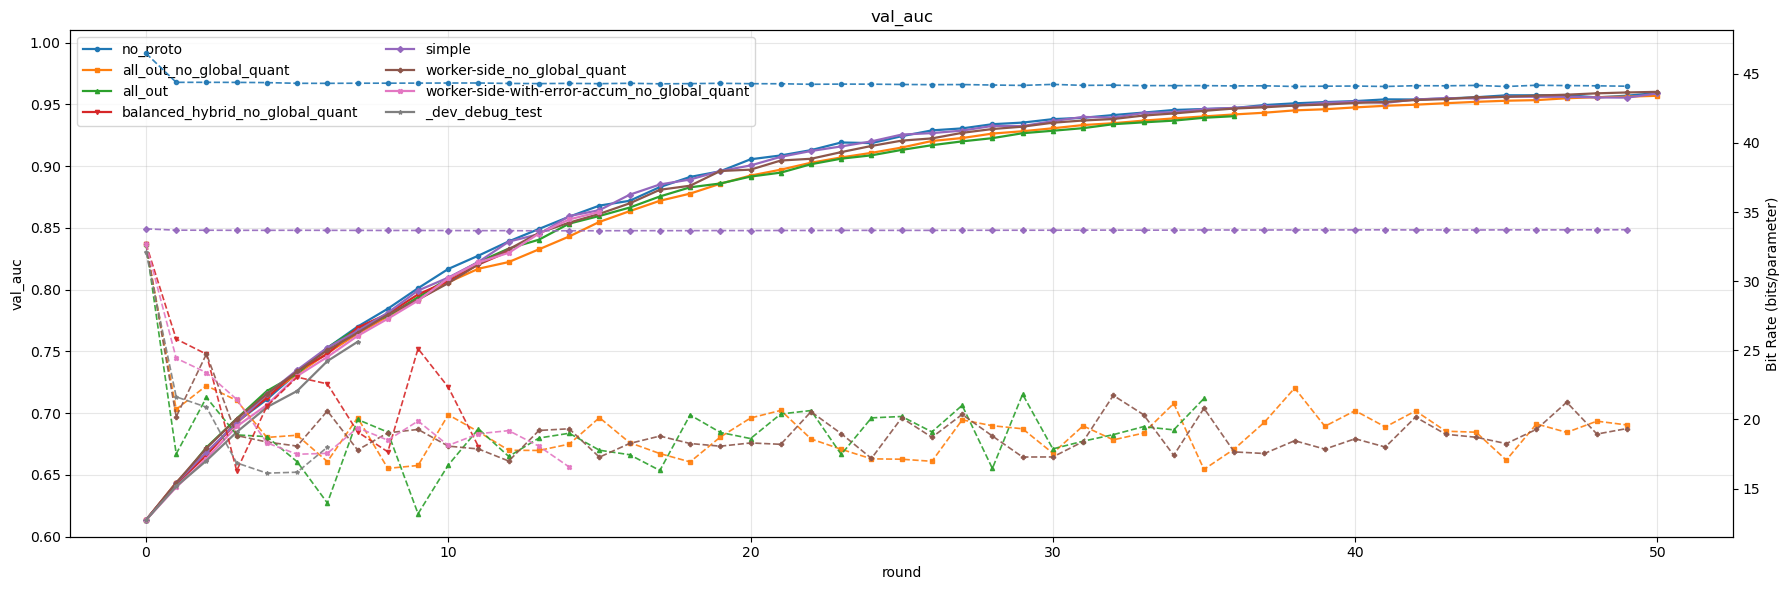

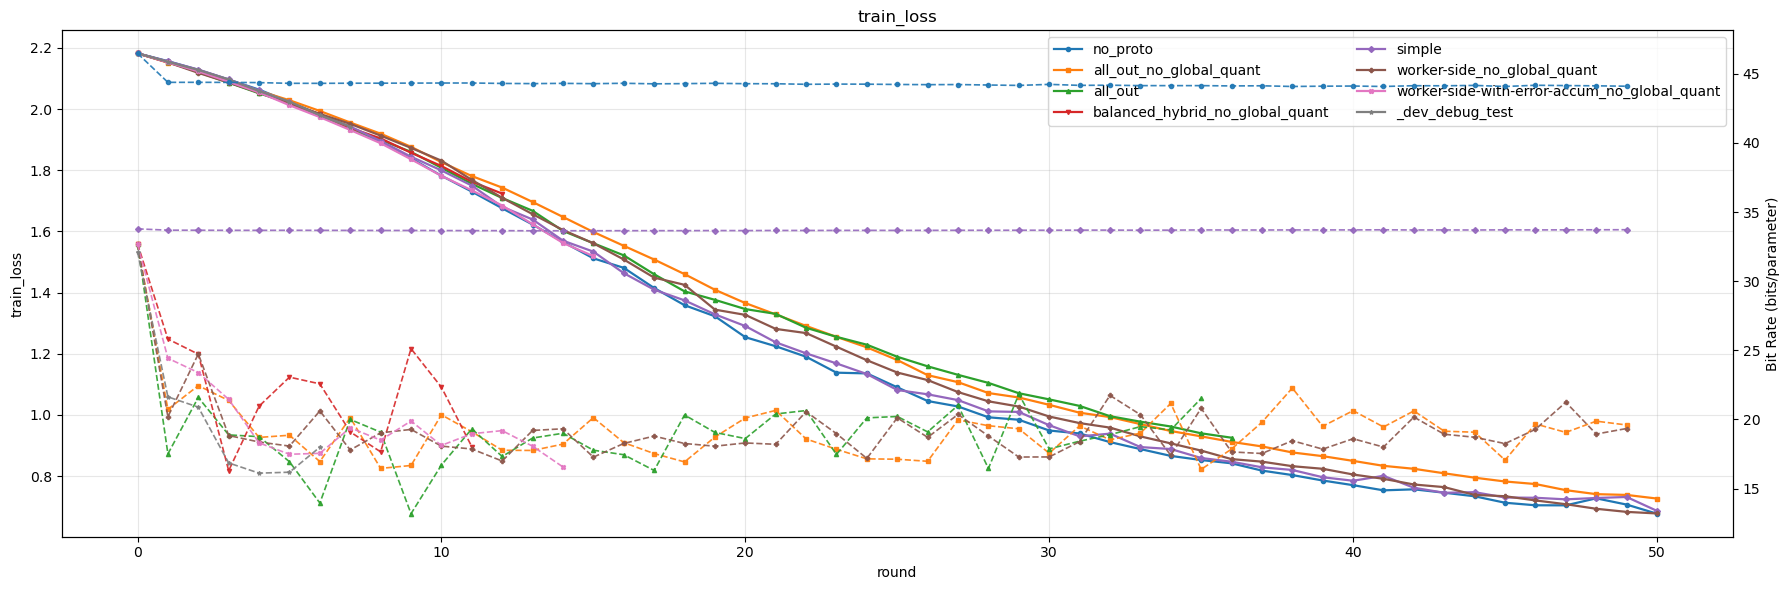

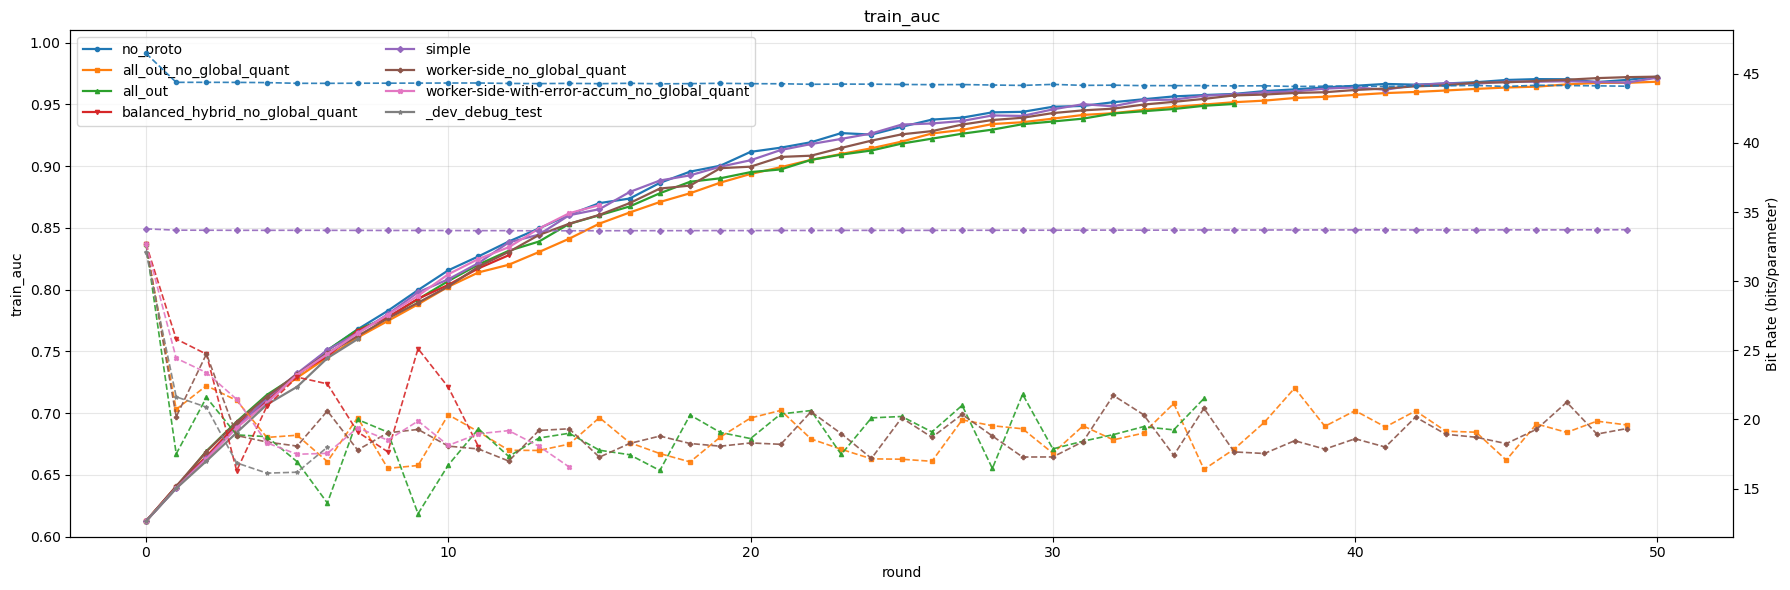

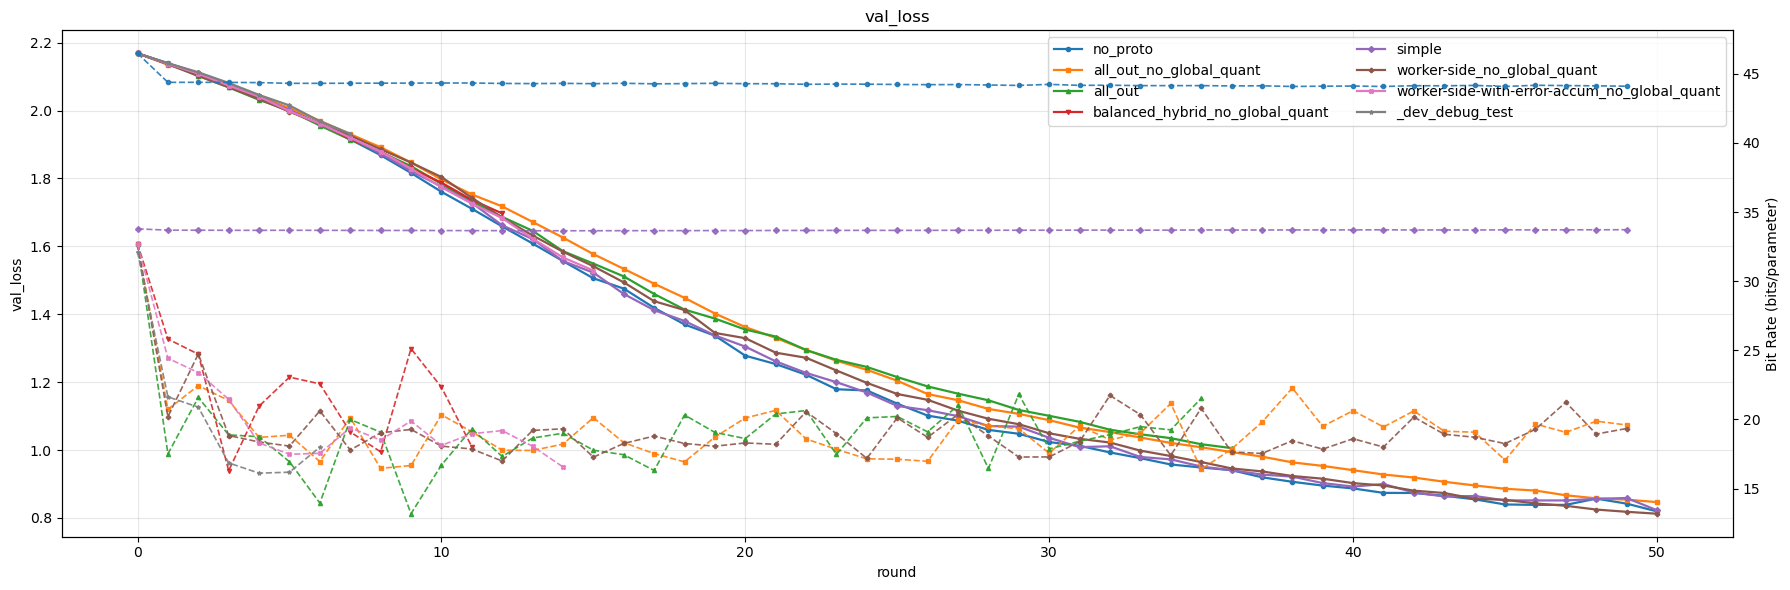

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import cycle, islice

total_params = 11_191_262
round_key = 'round_id'

# --- Build a big pool of distinguishable colors ---
# Start with color-blind friendly Tableau palettes and concatenate
def get_long_color_list():
    c = []
    for name in ['tab10', 'tab20', 'tab20b', 'tab20c']:
        c.extend(plt.cm.get_cmap(name).colors)
    # Remove near-duplicates by rounding (simple de-dupe)
    seen = set()
    uniq = []
    for r,g,b in c:
        key = (round(r,2), round(g,2), round(b,2))
        if key not in seen:
            seen.add(key)
            uniq.append((r,g,b))
    return uniq

all_colors = get_long_color_list()

# Prepare marker & linestyle cycles to help distinguish beyond color
marker_cycle = cycle(['o','s','^','v','D','P','X','*','<','>'])
linestyle_cycle_metric = cycle(['-'])          # metrics: solid
linestyle_cycle_br = cycle(['--'])             # bit-rate: dashed

keys_list = list(global_metric_before_round.keys())

# Assign each k a unique color + marker (repeat if more keys than options)
key_to_color = {k: all_colors[i % len(all_colors)] for i, k in enumerate(keys_list)}
key_to_marker = {k: next(marker_cycle) for k in keys_list}  # consumes n markers in order

for metric in ['val_auc', 'train_loss', 'train_auc', 'val_loss']:
    fig, ax = plt.subplots(figsize=(18, 6))
    ax2 = ax.twinx()

    metric_lines = []
    br_lines = []

    # Left axis: metric
    for k in keys_list:
        temp = global_metric_before_round[k]
        x = temp[round_key].values
        y = temp[metric].values
        (line,) = ax.plot(
            x, y,
            label=k,
            color=key_to_color[k],
            linestyle=next(linestyle_cycle_metric),
            marker=key_to_marker[k],
            markersize=3,
            linewidth=1.6
        )
        metric_lines.append(line)

    ax.set_title(metric)
    ax.set_xlabel('round')
    ax.set_ylabel(metric)
    ax.grid(True, which='both', alpha=0.3)
    if metric in ['val_auc', 'train_auc']:
        ax.set_ylim(0.6, 1.01)

    # Right axis: bit rate (reuse SAME color/marker, use dashed line)
    for k in keys_list:
        total_mb = 0
        for k_transfer in ['mbytes_recived', 'mbytes_sent_for_aggre', 'mbytes_sent_to_worker']:
            if k_transfer in broadcast_entire_stats[k]:
                total_mb += np.sum(broadcast_entire_stats[k][k_transfer], axis=1)

        bit_rate = (total_mb * 1024 * 1024 * 8) / total_params
        # bit_rate = np.mean(broadcast_entire_stats[k]['mape%'], axis=1)

        x = global_metric_before_round[k][round_key].values[:-1]

        (br_line,) = ax2.plot(
            x, bit_rate,
            # label=f'BR - {k}',
            color=key_to_color[k],      # same color
            linestyle='--',             # different style
            marker=key_to_marker[k],    # same marker
            markersize=3,
            linewidth=1.2,
            alpha=0.9
        )
        # br_lines.append(br_line)

    ax2.set_ylabel('Bit Rate (bits/parameter)')
    # ax2.set_ylabel('MSPE%')
    ax2.tick_params(axis='y')
    ax2.grid(False)

    # Combined legend, split in columns to avoid mega-tall legends
    lines = metric_lines + br_lines
    labels = [l.get_label() for l in lines]
    ax.legend(lines, labels, loc='best', ncol=2, frameon=True)

    plt.tight_layout()
    plt.show()





 no_proto



 all_out



 balanced_hybrid



 hybrid



 no_proto_only_global



 simple


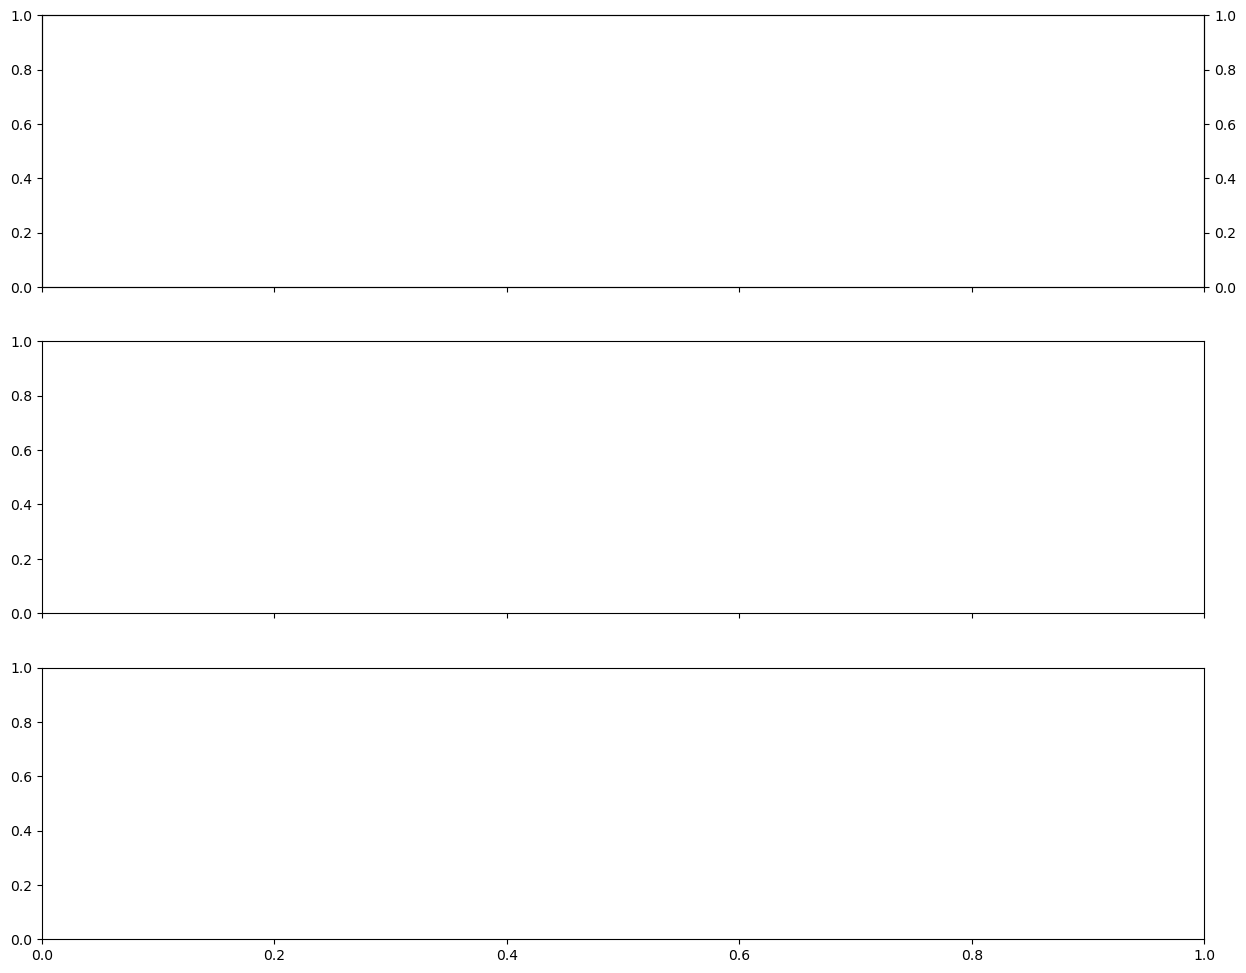

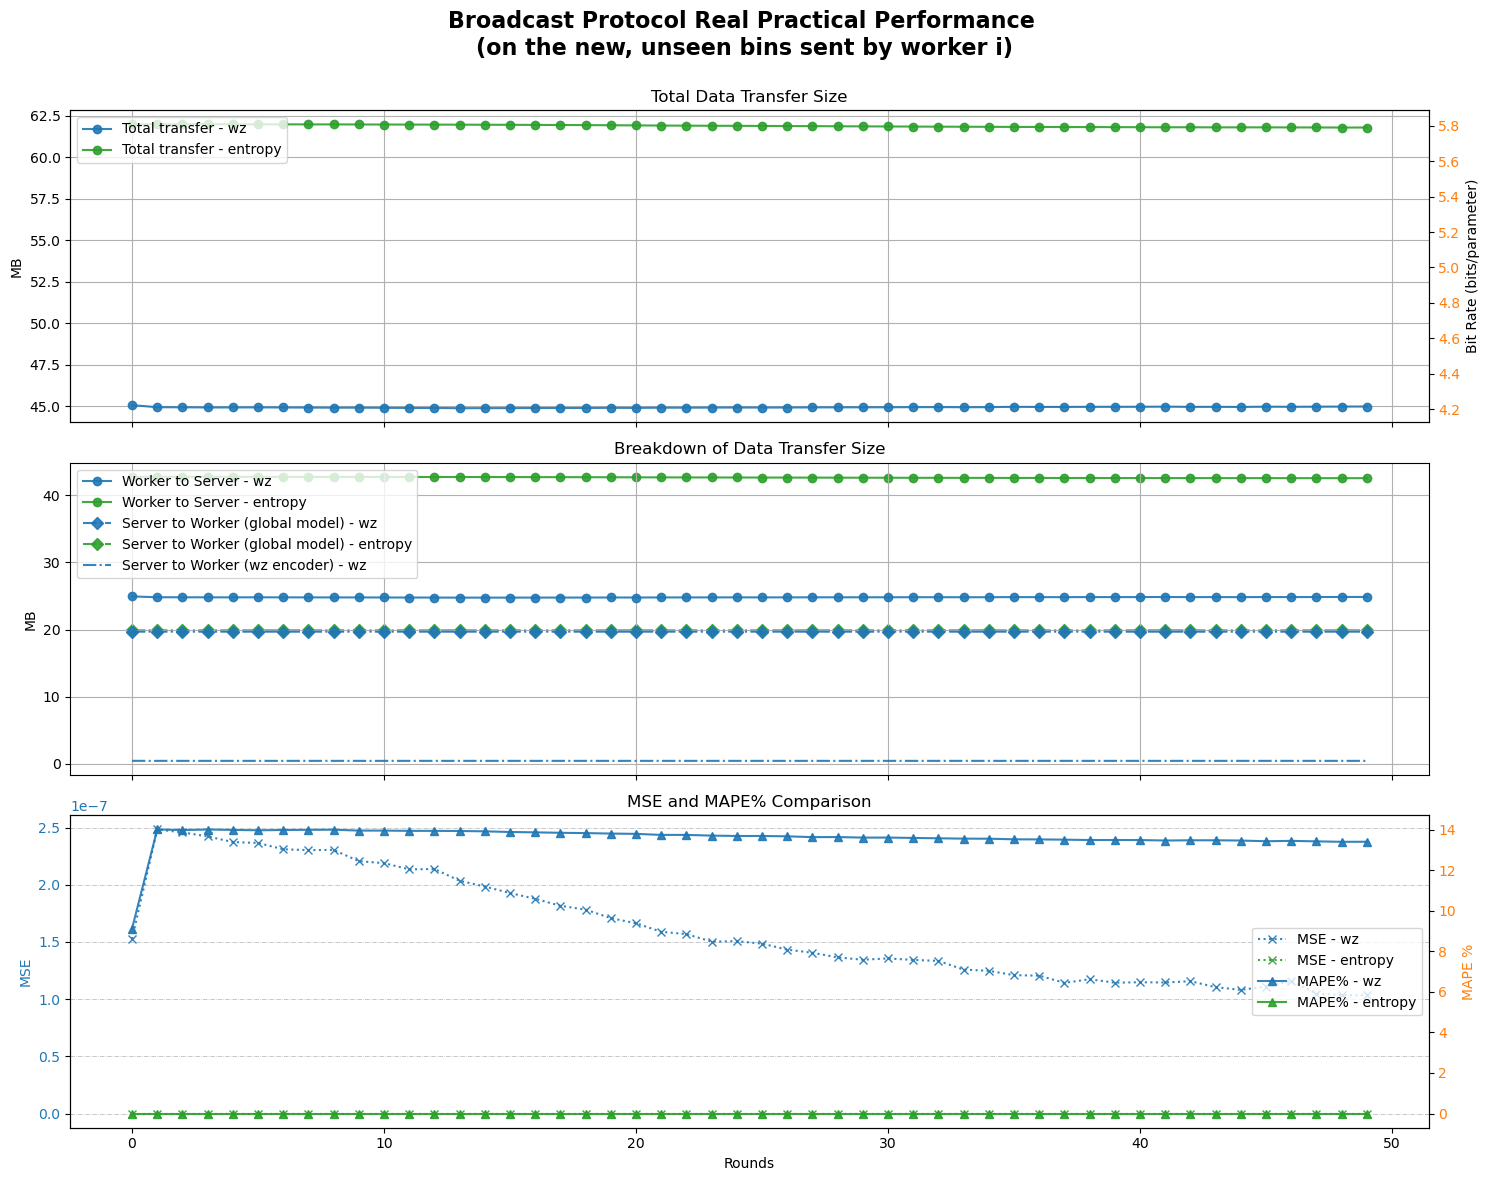

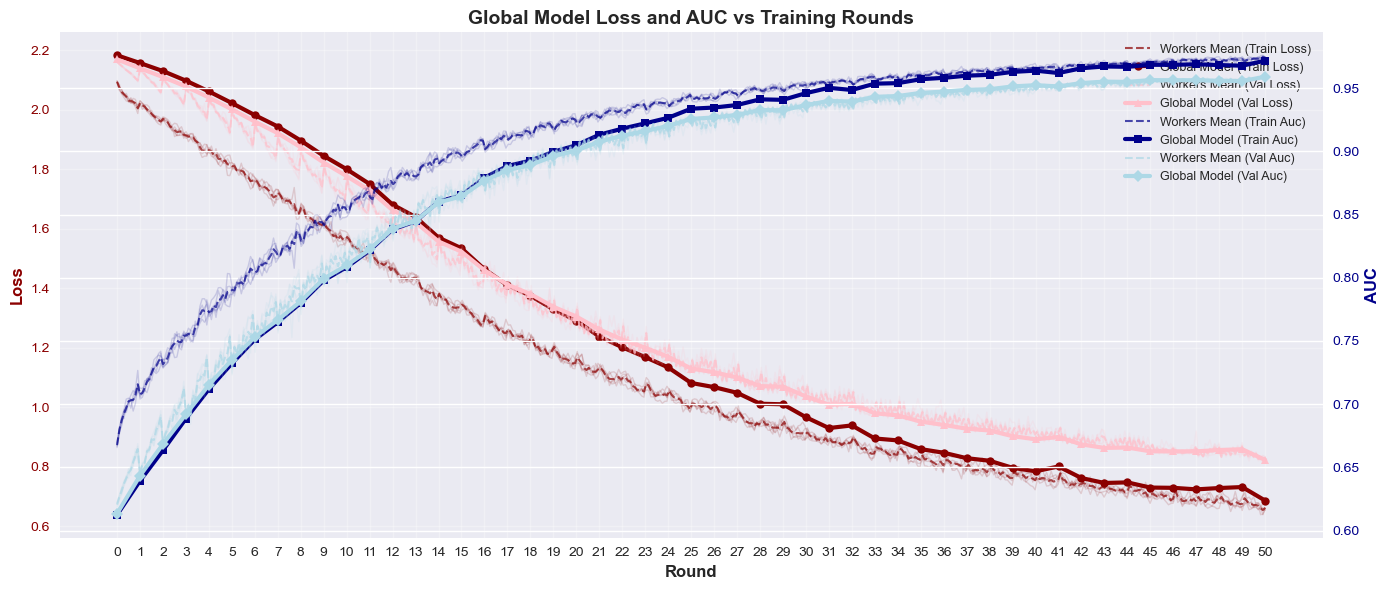

D:\User\Software\Miniconda3\envs\UniversalCondaEnv\Lib\site-packages\numpy\_core\fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
D:\User\Software\Miniconda3\envs\UniversalCondaEnv\Lib\site-packages\numpy\_core\_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


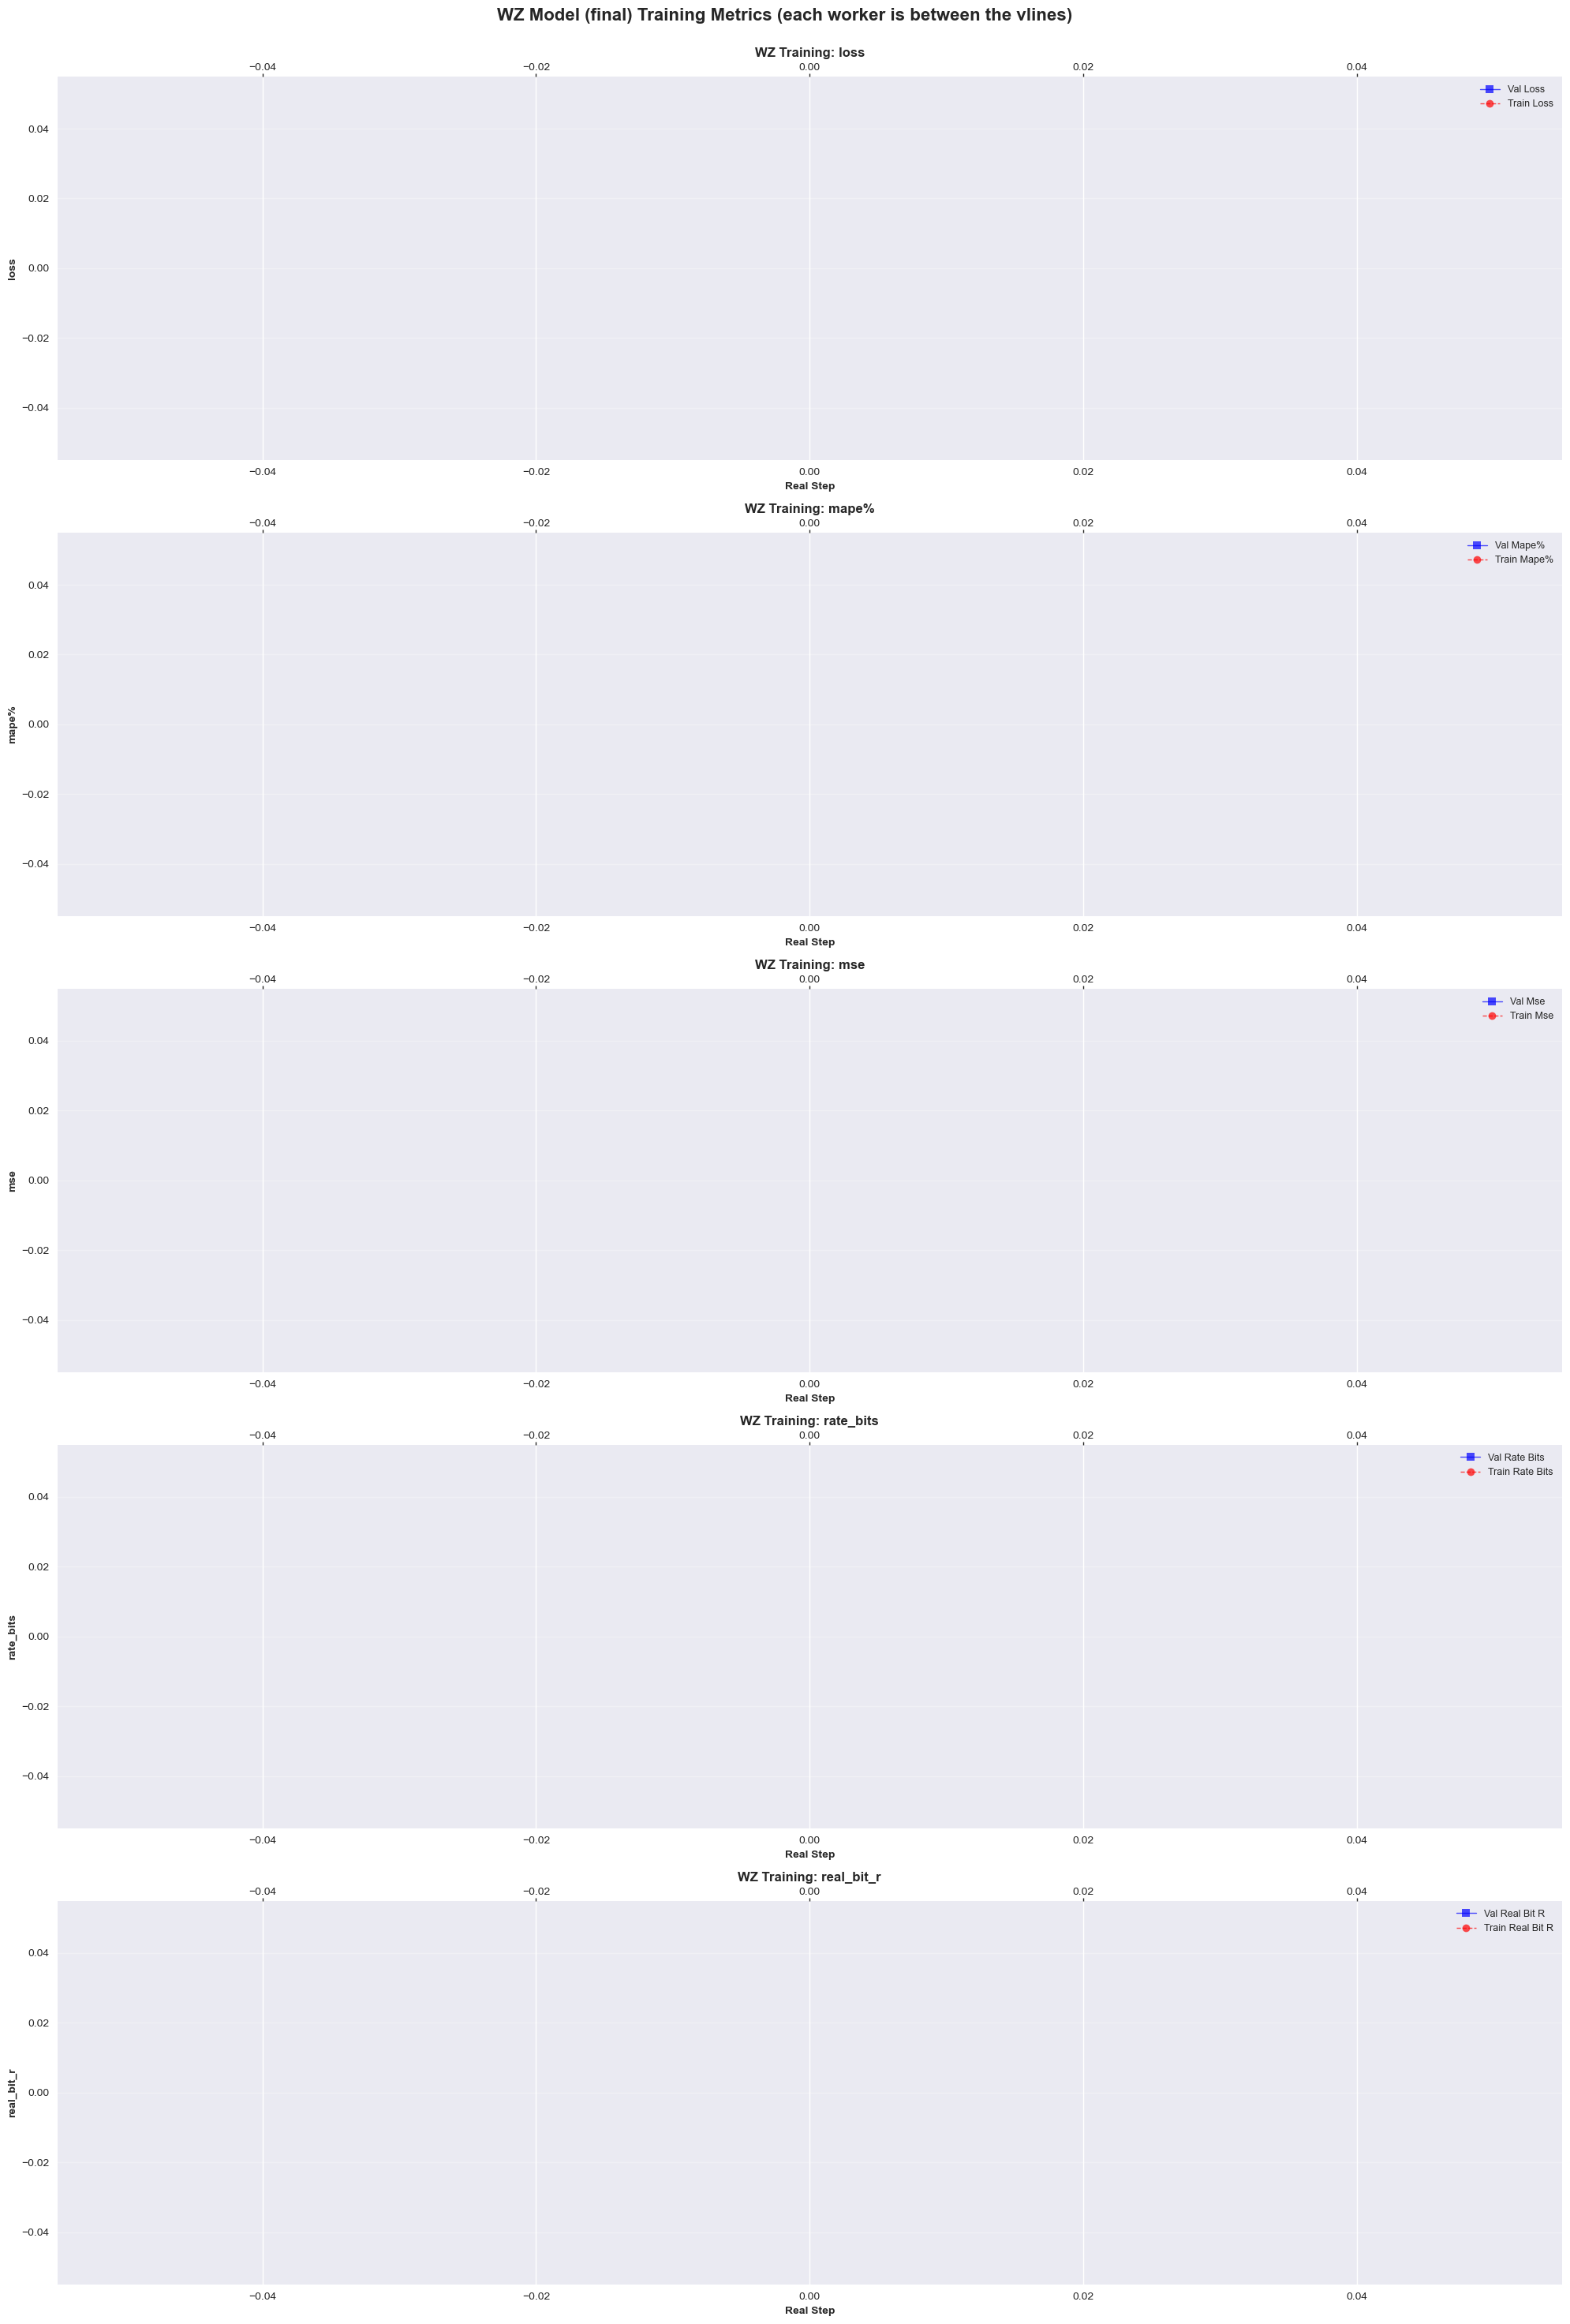

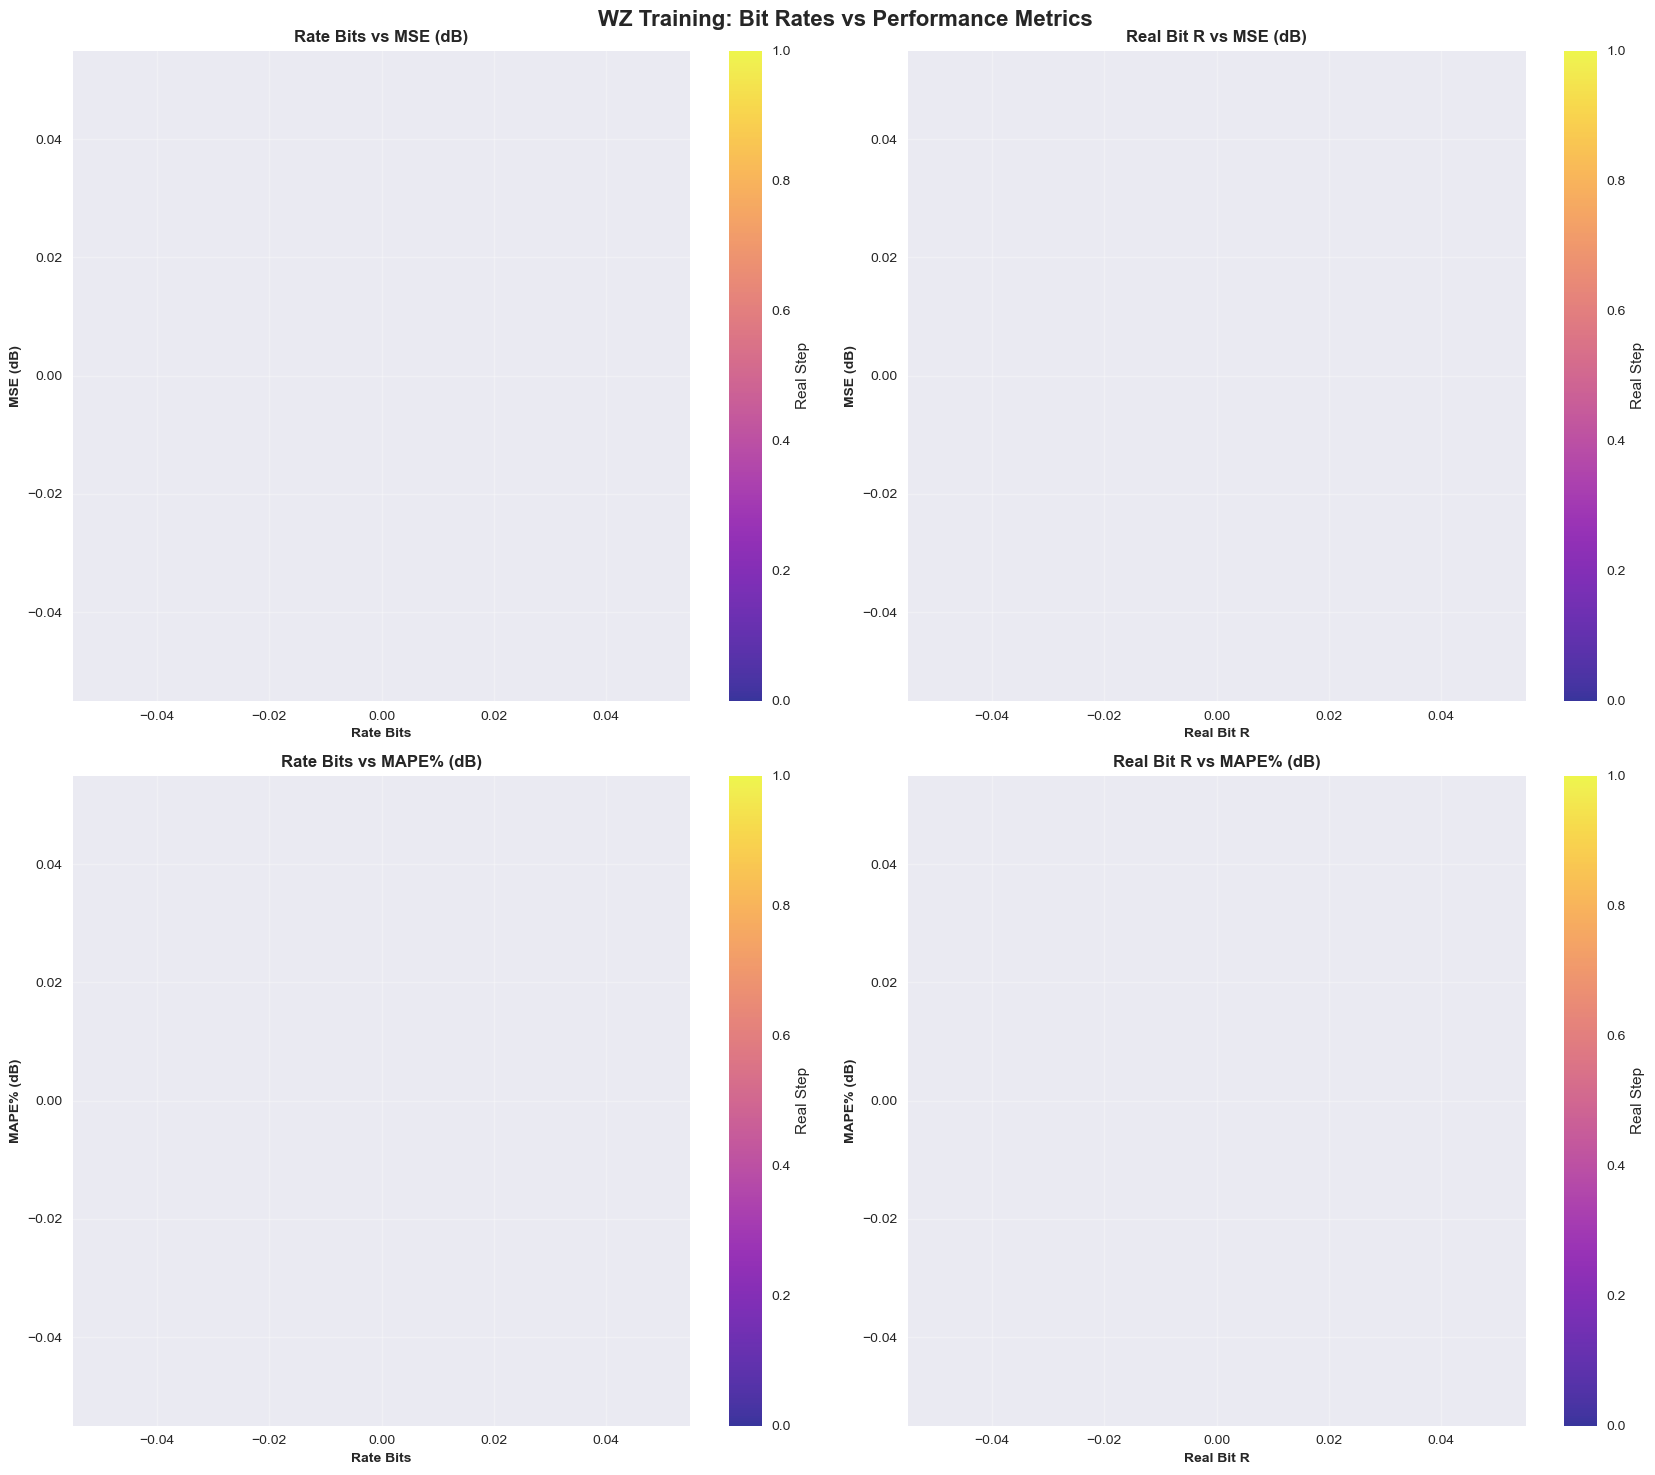




 worker-side



 worker-side-with-error-accum



 0



 1



 2



 3



 4



 5



 6



 7



 01



 02



 03



 04



 05



 06



 07



 10



 12



 13



 14



 15



 16



 17



 20



 21



 23



 24



 25



 26



 27



 30



 31



 32



 34



 35



 36



 37



 40



 41



 42



 43



 45



 46



 47



 50



 51



 52



 53



 54



 56



 57



 60



 61



 62



 63



 64



 65



 67



 70



 71



 72



 73



 74



 75



 76



 012



 013



 014



 015



 016



 017



 021



 023



 024



 025



 026



 027



 031



 032



 034



 035



 036



 037



 041



 042



 043



 045



 046



 047



 051



 052



 053



 054



 056



 057



 061



 062



 063



 064



 065



 067



 071



 072



 073



 074



 075



 076



 102



 103



 104



 105



 106



 107



 120



 123



 124



 125



 126



 127



 130



 132



 134



 135



 136



 137



 140



 142



 143



 145

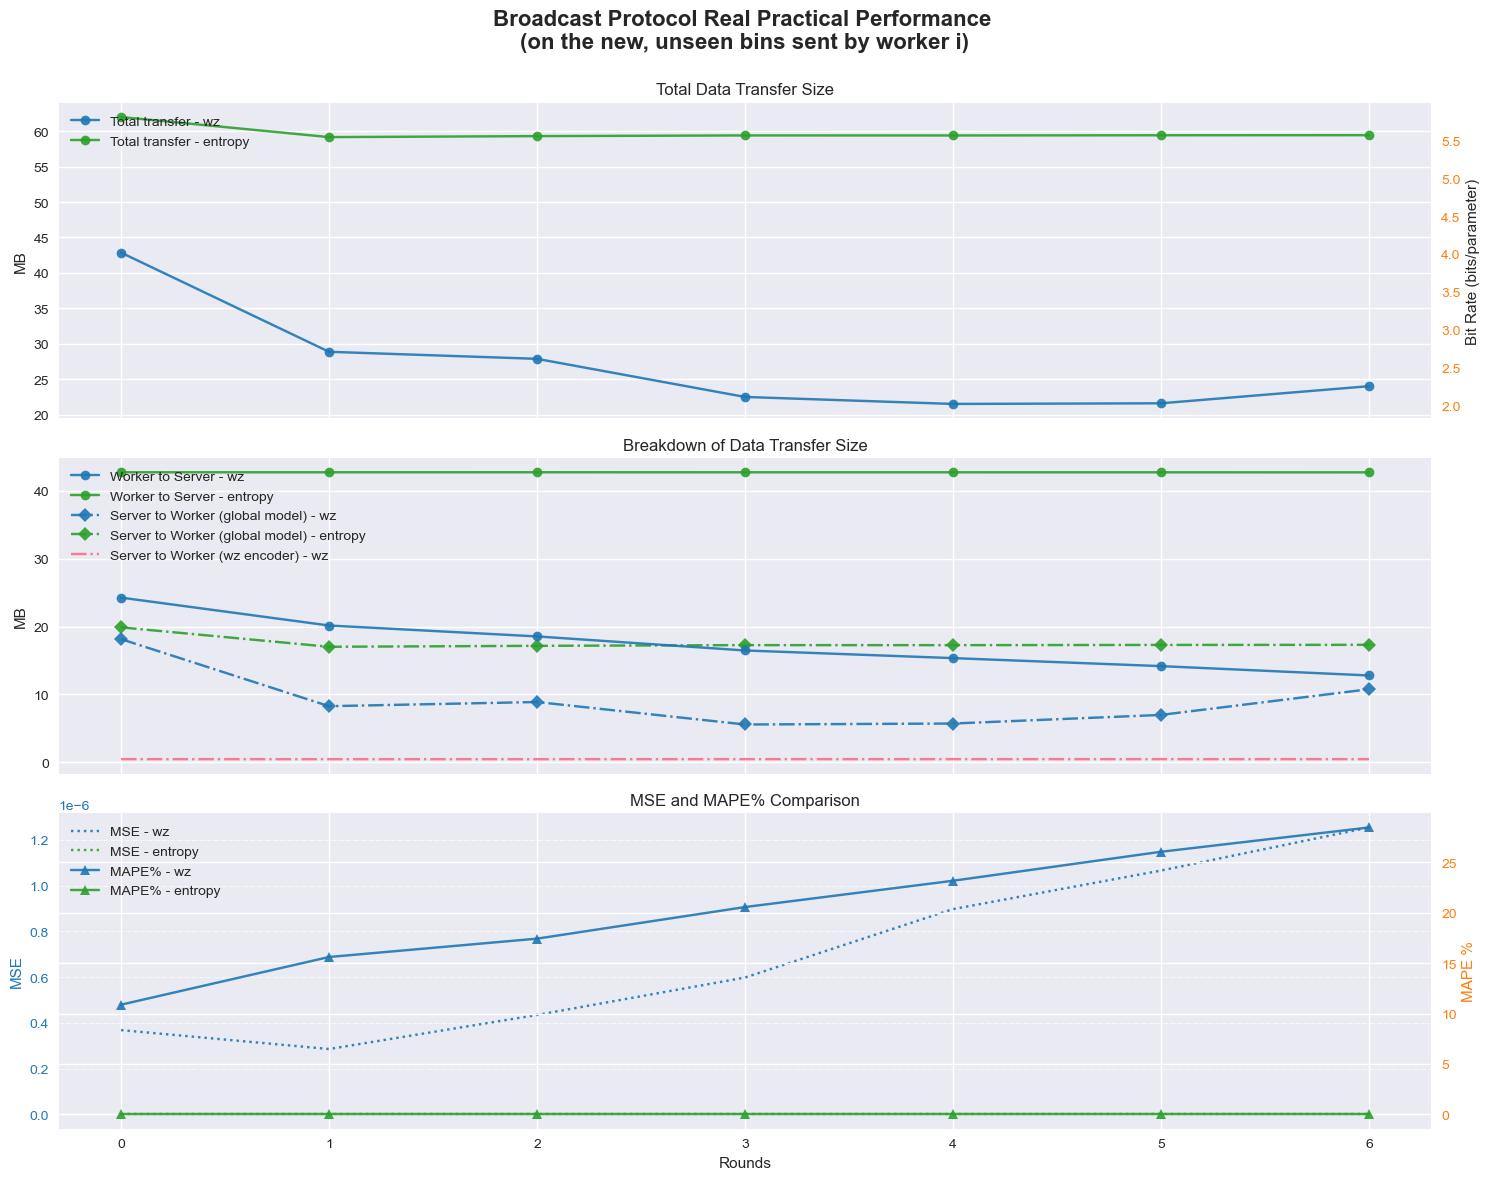

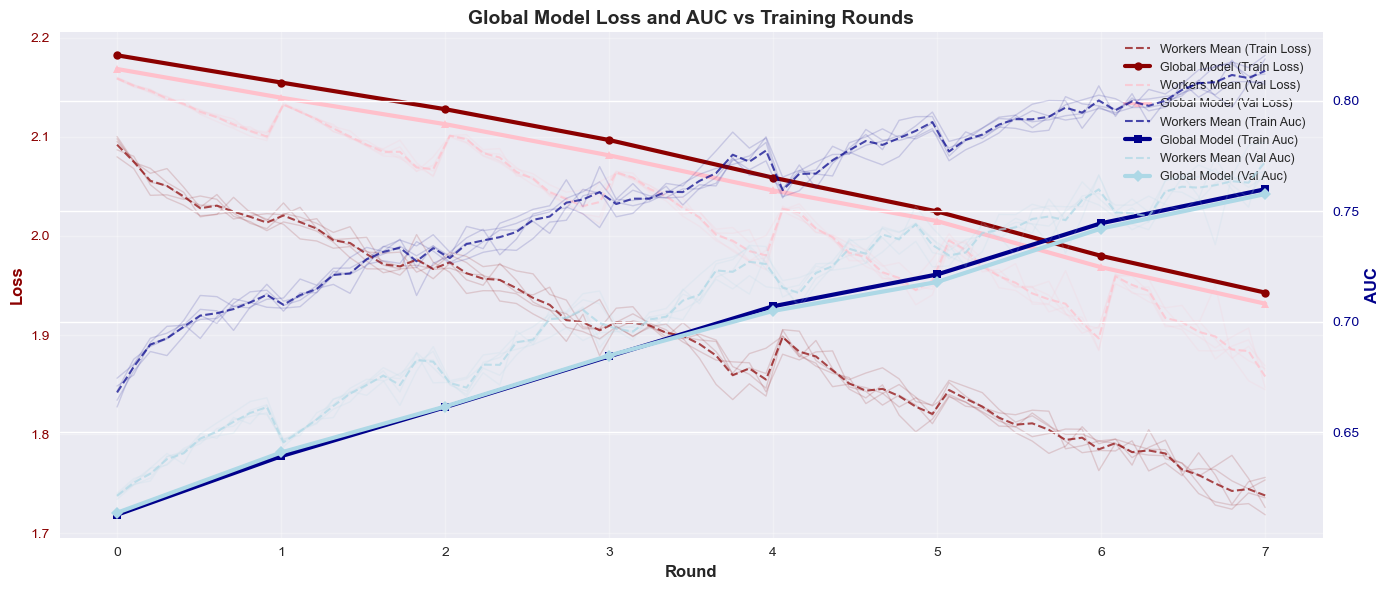

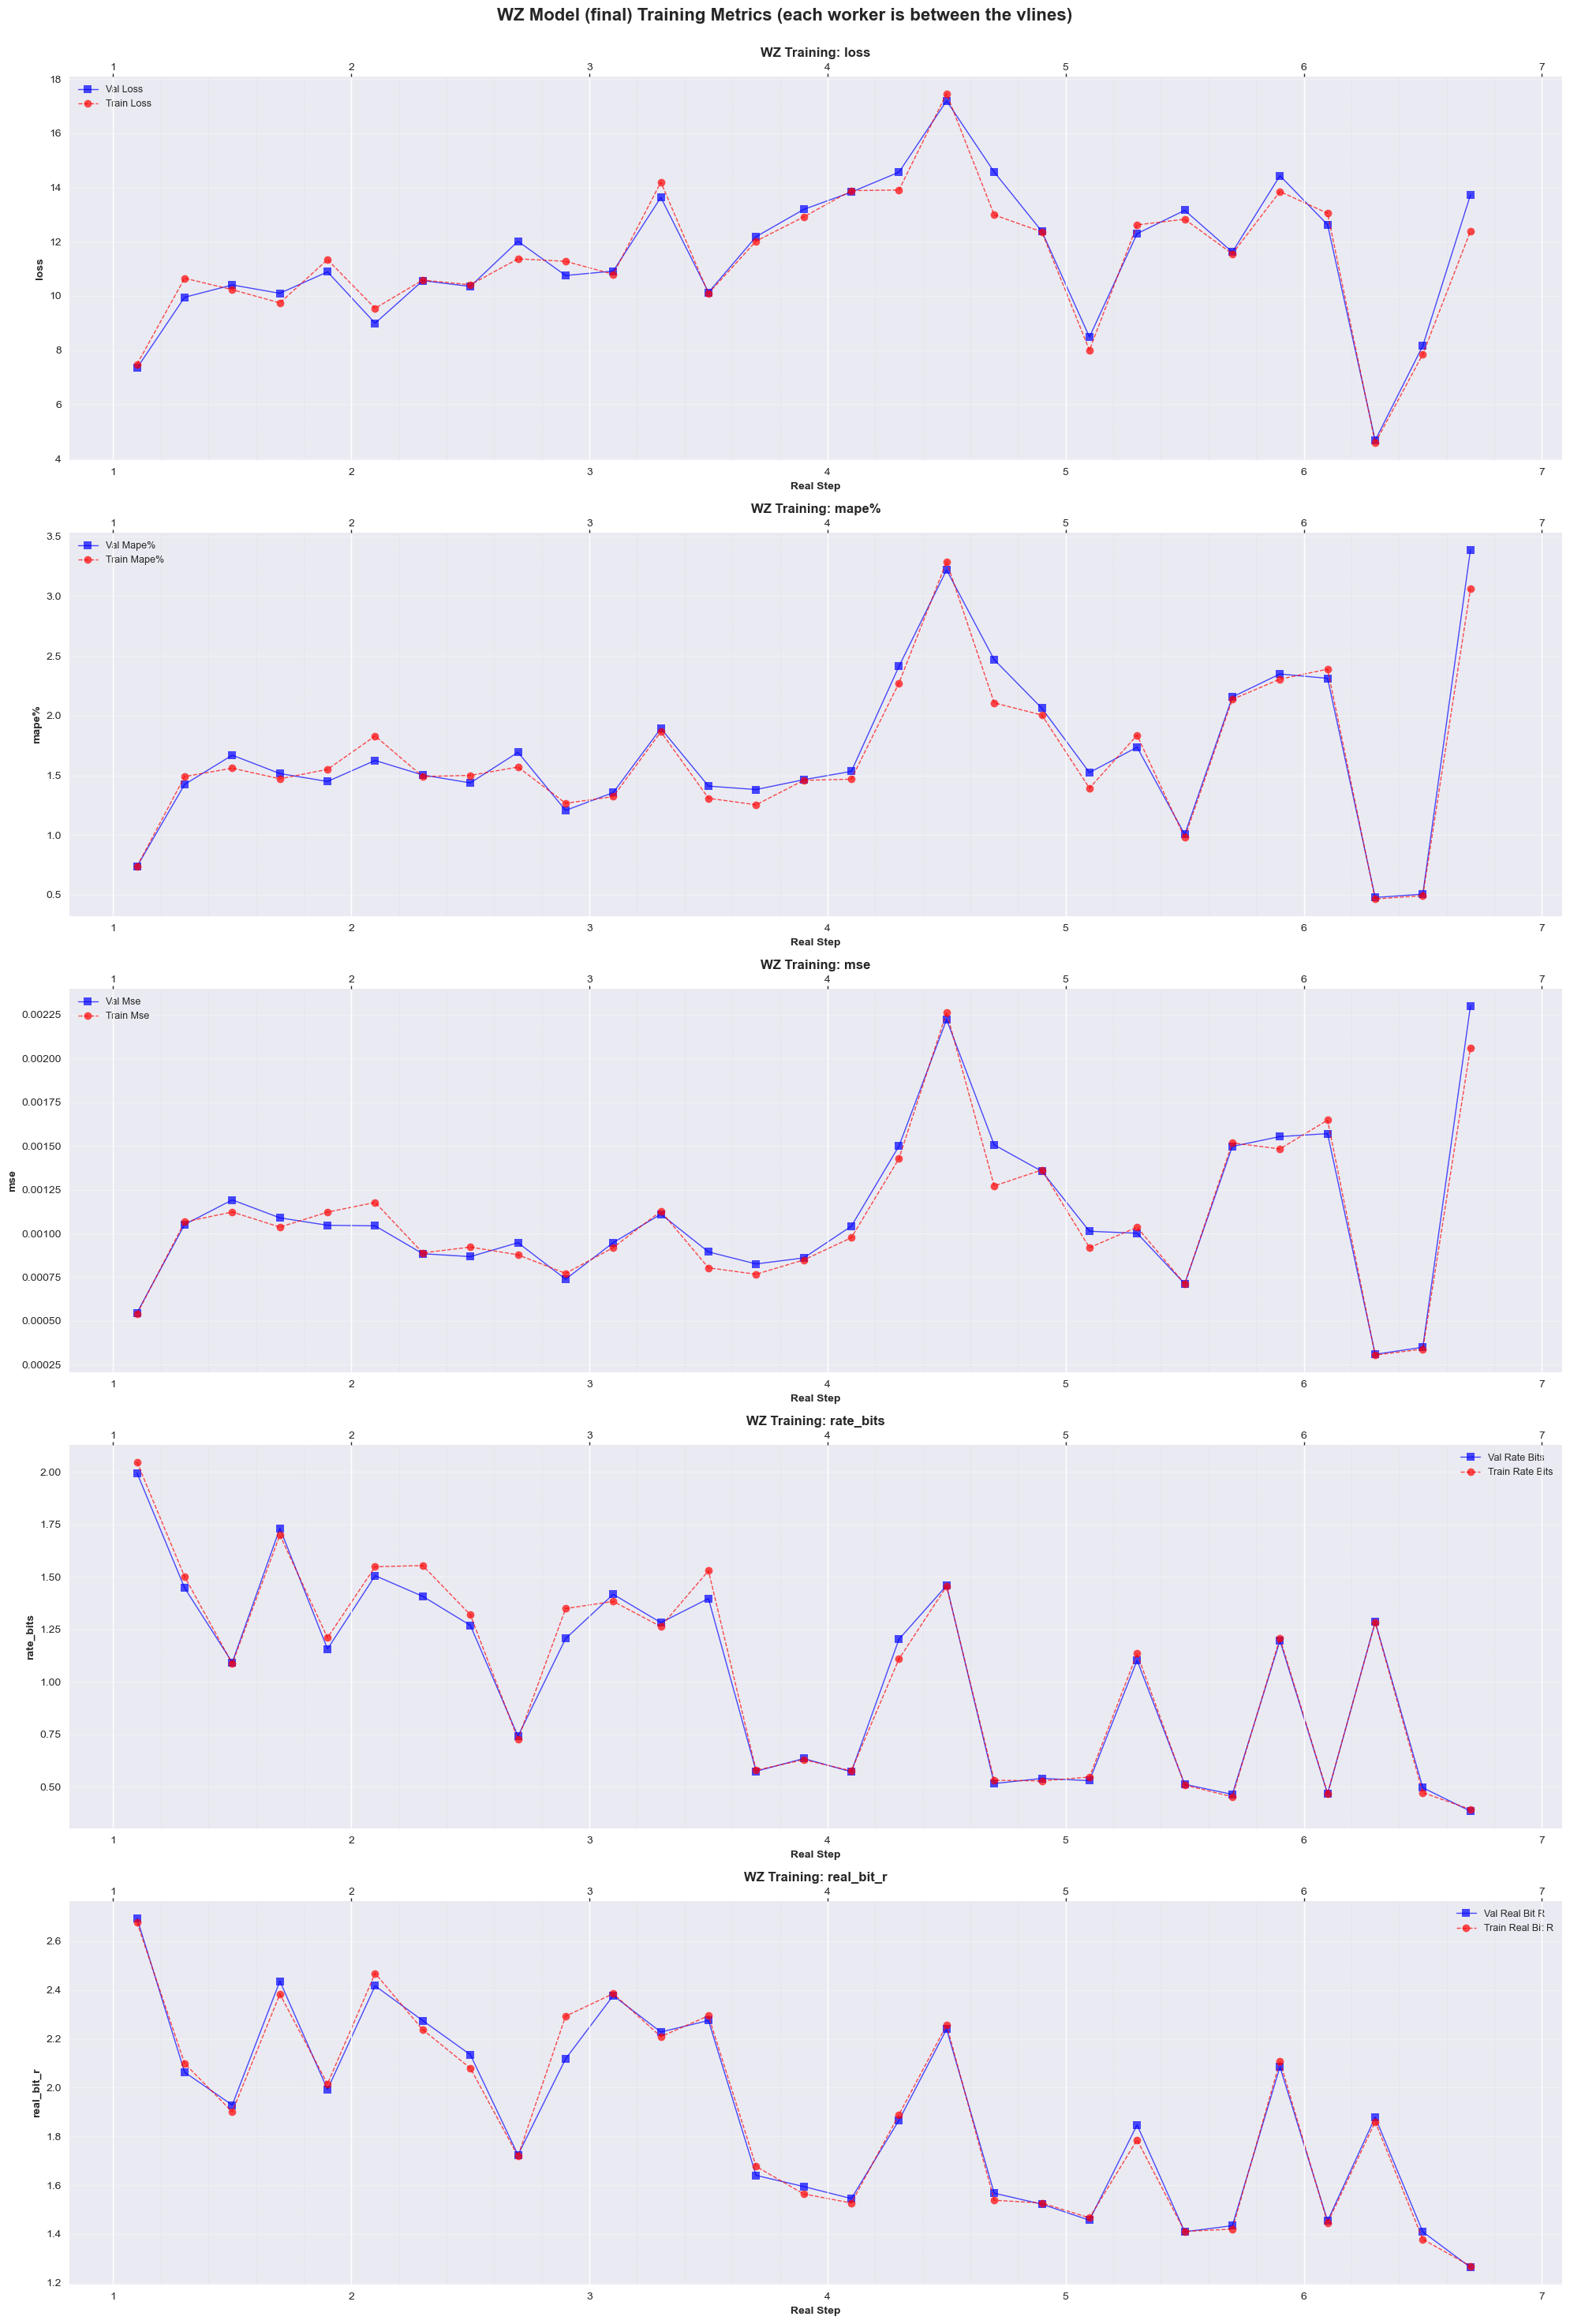

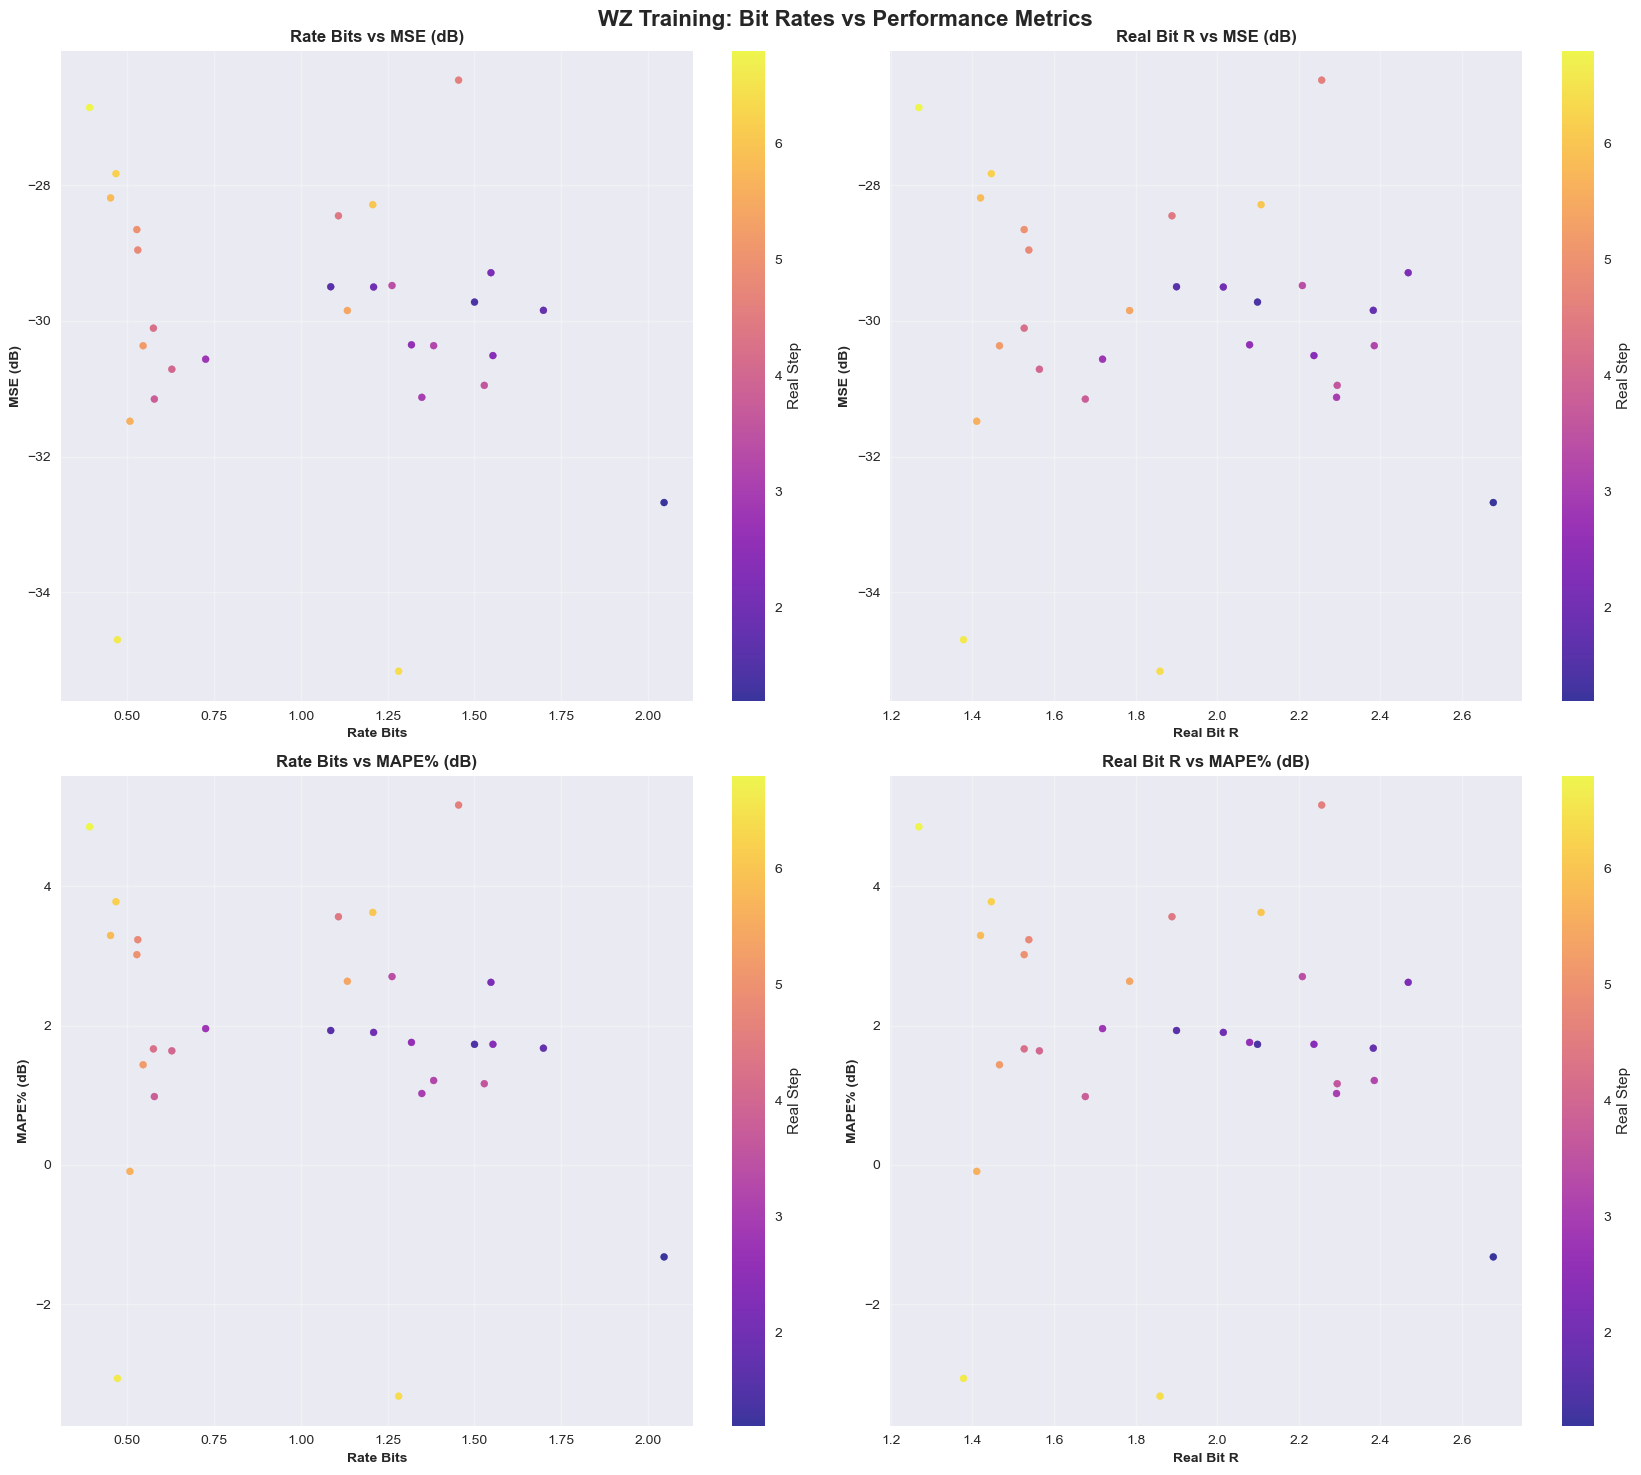

In [4]:
for p_name in proto_choices:
    print('\n\n\n', p_name)
    try:
        report_data=get_unified_data_tables(p_name, 5)
        plot_all_metrics(*report_data)
    except:
        pass